# Product Segmentation Case Study

## Context

When you think of sneakers for a trip, the importance of good footwear cannot be discarded, and the obvious brands that come to mind are Adidas and Nike. Adidas vs Nike is a constant debate as the two giants in the apparel market, with a large market cap and market share, battle it out to come on top. As a newly hired Data Scientist in a market research company, you have been given the task of extracting insights from the data of men's and women's shoes, and grouping products together to identify similarities and differences between the product range of these renowned brands.

## Let's start coding!

### Importing necessary libraries

In [ ]:
# please uncomment and run the next line if yellowbrick library is not previously installed
#!pip install yellowbrick

In [ ]:

!pip nb_black


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()


pd.set_option("display.max_columns", None)

pd.set_option("display.max_rows", 200)


from sklearn.preprocessing import StandardScaler


from scipy.spatial.distance import cdist


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

ERROR: unknown command "nb_black"


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:

data = pd.read_csv("/content/drive/MyDrive/機器學習/Mall_Customers dataset.csv")

In [ ]:
data.shape

(200, 5)

In [ ]:

data.sample(n=10, random_state=1)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
58,59,Female,27,46,51
40,41,Female,65,38,35
34,35,Female,49,33,14
102,103,Male,67,62,59
184,185,Female,41,99,39
198,199,Male,32,137,18
95,96,Male,24,60,52
4,5,Female,31,17,40
29,30,Female,23,29,87
168,169,Female,36,87,27


In [ ]:

df = data.copy()

In [ ]:

df.columns = [c.replace(" ", "_") for c in df.columns]

In [ ]:
# let's look at the structure of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual_Income_(k$)      200 non-null    int64 
 4   Spending_Score_(1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


**We won't need Product_ID for analysis, so let's drop this column.**

In [ ]:
df.drop("CustomerID", axis=1, inplace=True)

In [ ]:

df.duplicated().sum()

np.int64(0)

In [ ]:
df = df[(~df.duplicated())].copy()

**Let's take a look at the summary of the data**

In [ ]:
df.describe()

,Age,Annual_Income_(k$),Spending_Score_(1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [ ]:

(df['Annual_Income_(k$)'] == 0).sum()

np.int64(0)

In [ ]:

df[(df["Annual_Income_(k$)"] == 0)]

,Genre,Age,Annual_Income_(k$),Spending_Score_(1-100)


In [ ]:
df[(df['Annual_Income_(k$)'] == 0)].describe()

,Age,Annual_Income_(k$),Spending_Score_(1-100)
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


In [ ]:
df.loc[(df["Annual_Income_(k$)"] == 0), ["Annual_Income_(k$)"]] = df.loc[
    (df["Annual_Income_(k$)"] == 0), ["Age"]
].values

In [ ]:
df['Annual_Income_(k$)'].describe()

,Annual_Income_(k$)
count,200.000000
mean,60.560000
std,26.264721
min,15.000000
25%,41.500000
50%,61.500000
75%,78.000000
max,137.000000


In [ ]:

df.isna().sum()

,0
Genre,0
Age,0
Annual_Income_(k$),0
Spending_Score_(1-100),0


- There are no missing values in the data.

## EDA

In [ ]:



def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )

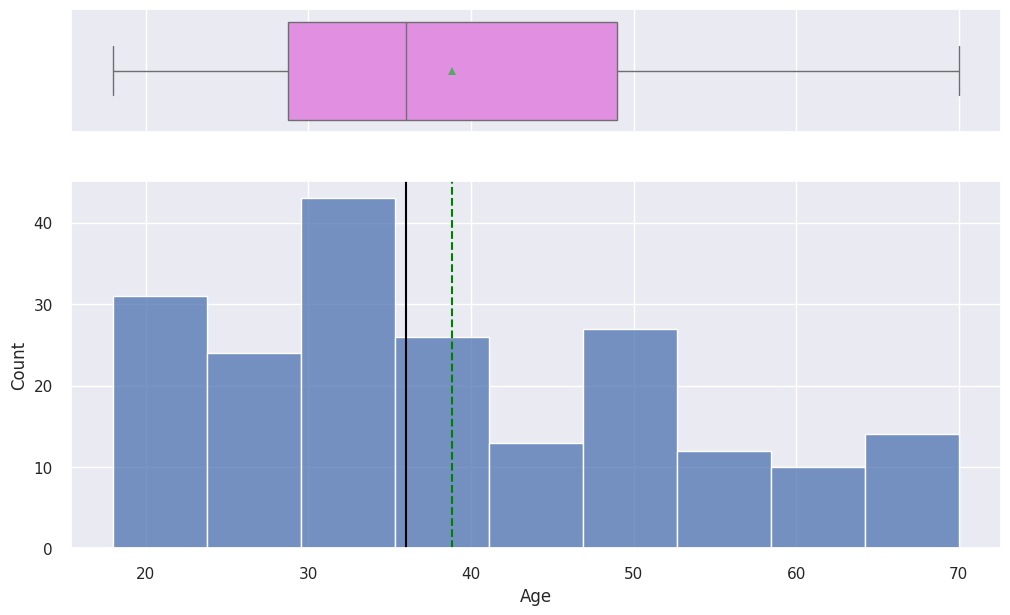

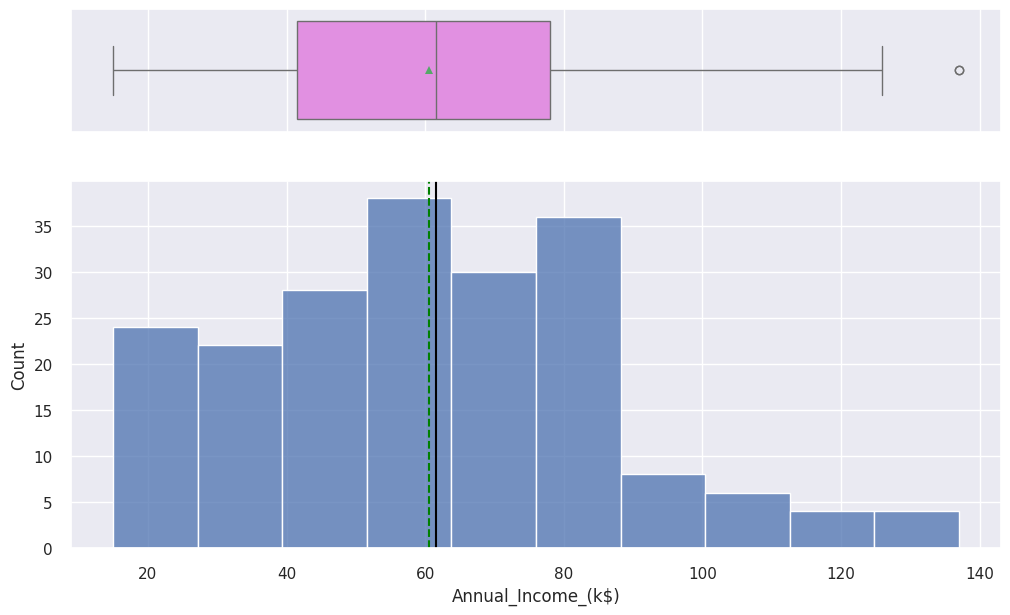

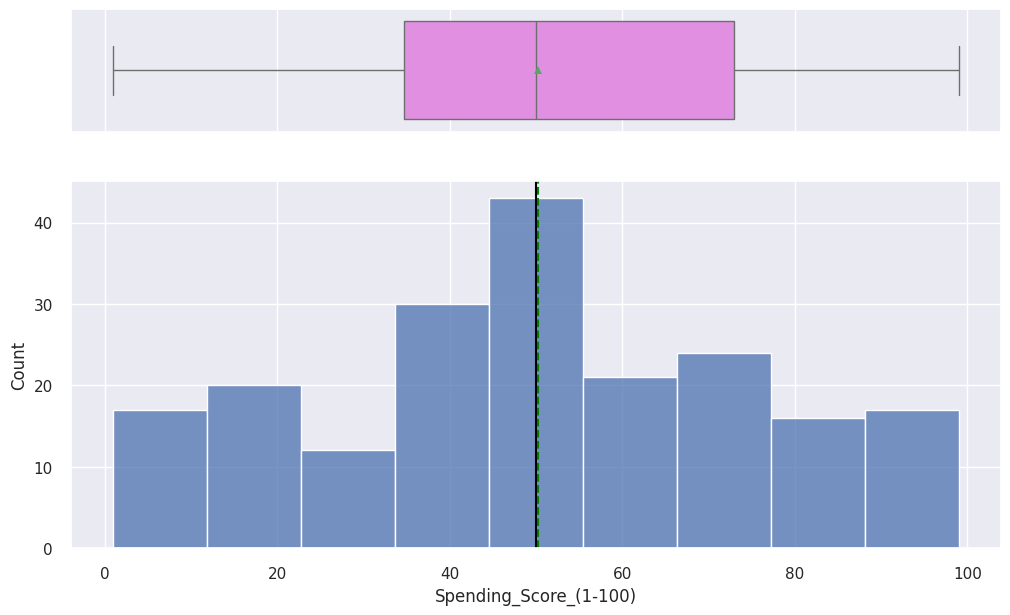

In [ ]:

num_col = df.select_dtypes(include=np.number).columns.tolist()

for item in num_col:
    histogram_boxplot(df, item)

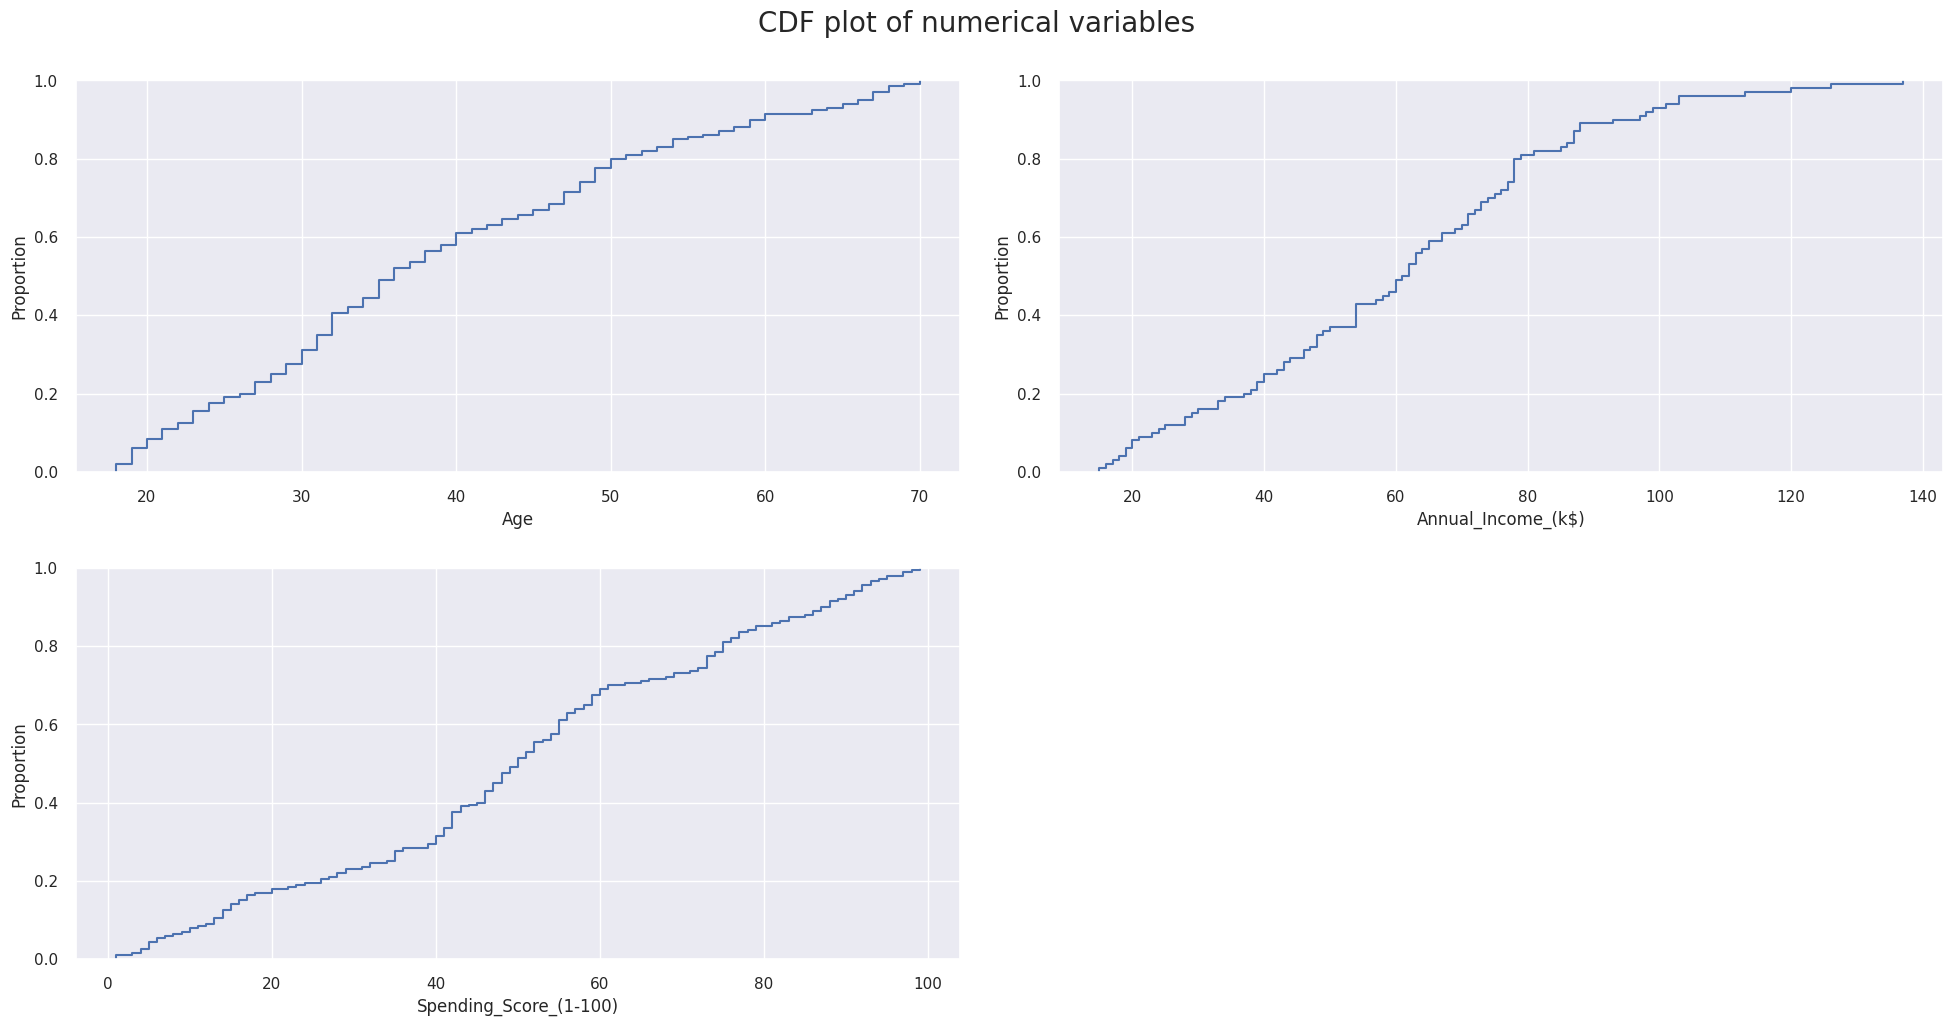

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
fig.suptitle("CDF plot of numerical variables", fontsize=20)
axes = axes.flatten()


for i, col in enumerate(num_col):
    if i < len(axes):
        sns.ecdfplot(ax=axes[i], x=df[col])


for j in range(len(num_col), len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout(pad=2.0)
plt.show()

In [ ]:



def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )
        else:
            label = p.get_height()

        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    plt.show()

/tmp/ipykernel_1509/2603305575.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


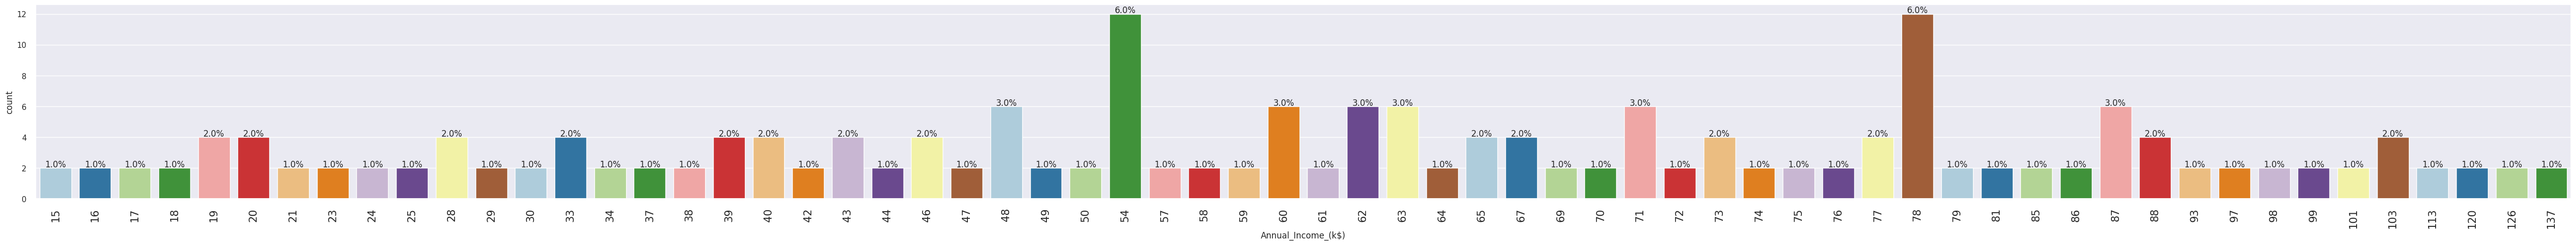

In [ ]:

labeled_barplot(df, "Annual_Income_(k$)", perc=True)

## Bivariate Analysis

**Let's check for correlations.**

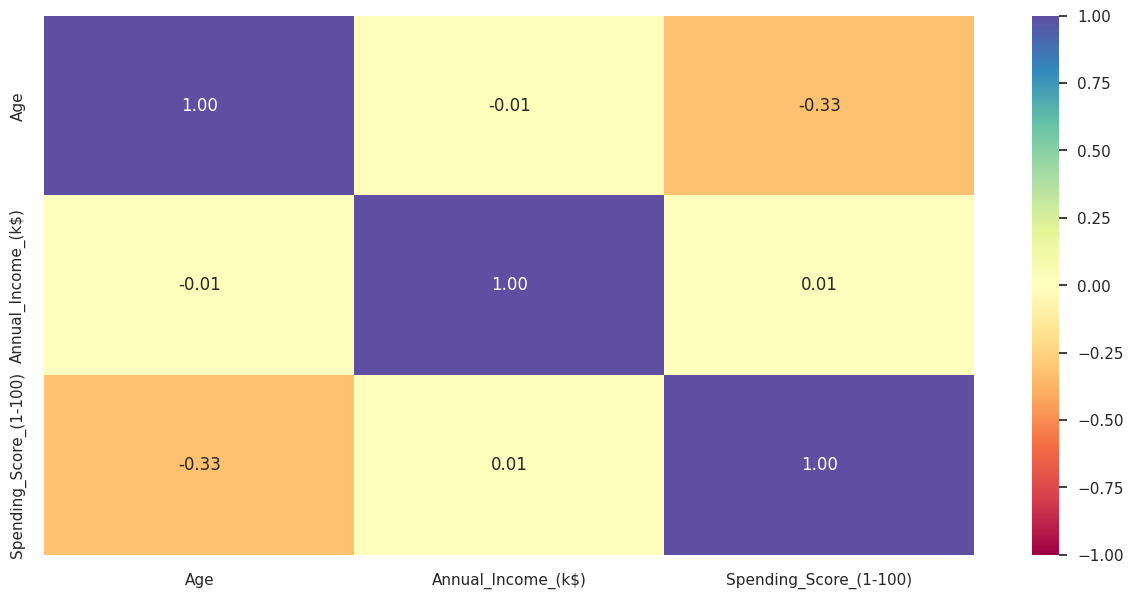

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(df[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

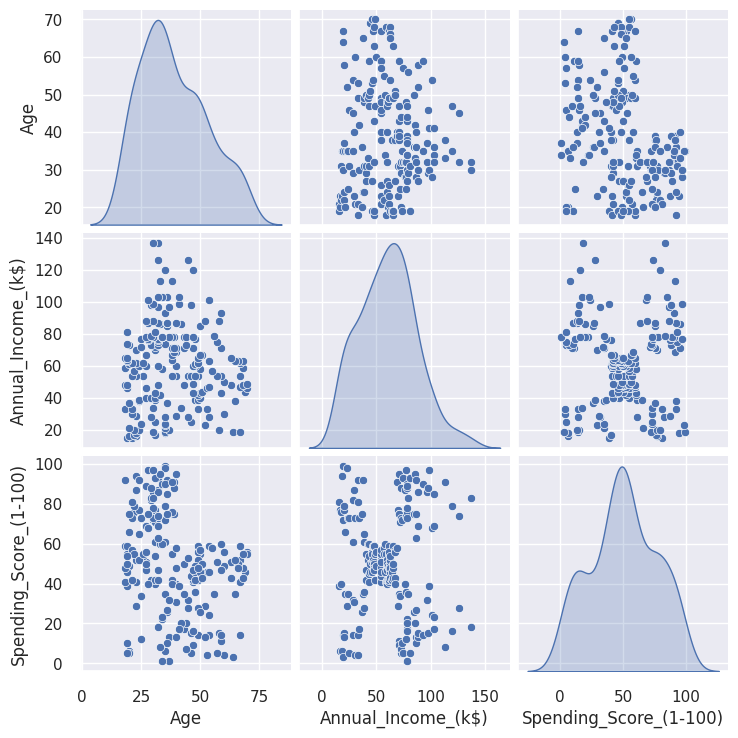

In [ ]:
sns.pairplot(data=df[num_col], diag_kind="kde")
plt.show()

## Data Preprocessing

In [ ]:

num_col

['Age', 'Annual_Income_(k$)', 'Spending_Score_(1-100)']

In [ ]:

scaler = StandardScaler()
subset = df[num_col].copy()
subset_scaled = scaler.fit_transform(subset)

In [ ]:

subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

## K-means Clustering

Number of Clusters: 1 	Average Distortion: 1.620358556077695
Number of Clusters: 2 	Average Distortion: 1.295873549009658
Number of Clusters: 3 	Average Distortion: 1.1236965531576244
Number of Clusters: 4 	Average Distortion: 0.9284580379679376
Number of Clusters: 5 	Average Distortion: 0.8579285566032773
Number of Clusters: 6 	Average Distortion: 0.8073562604550244
Number of Clusters: 7 	Average Distortion: 0.6779662127249056
Number of Clusters: 8 	Average Distortion: 0.6462409047980066


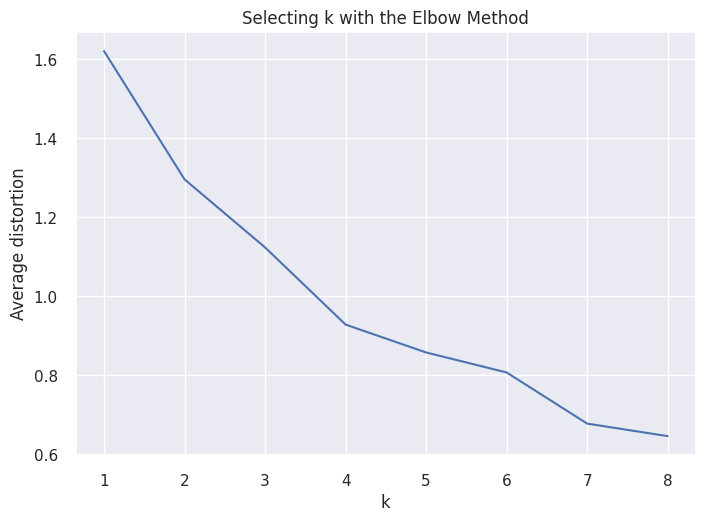

In [ ]:
clusters = range(1, 9)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k)
    model.fit(subset_scaled_df)
    prediction = model.predict(subset_scaled_df)
    distortion = (
        sum(
            np.min(cdist(subset_scaled_df, model.cluster_centers_, "euclidean"), axis=1)
        )
        / subset_scaled_df.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average distortion")
plt.title("Selecting k with the Elbow Method")
plt.show()

**Let's check the silhouette scores.**

For n_clusters = 2, the silhouette score is 0.33547192894004574)
For n_clusters = 3, the silhouette score is 0.3521192491387368)
For n_clusters = 4, the silhouette score is 0.4039582785148566)
For n_clusters = 5, the silhouette score is 0.41664341513732767)
For n_clusters = 6, the silhouette score is 0.429210925806494)
For n_clusters = 7, the silhouette score is 0.4100425339646943)
For n_clusters = 8, the silhouette score is 0.40344225134802625)
For n_clusters = 9, the silhouette score is 0.3881188891469111)


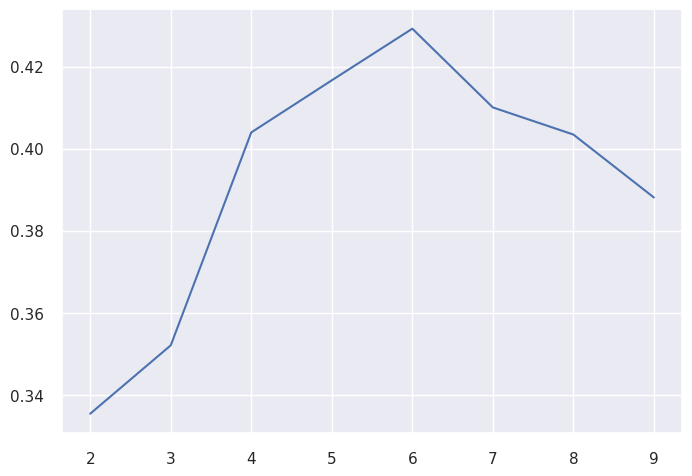

In [ ]:
sil_score = []
cluster_list = list(range(2, 10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict((subset_scaled_df))

    score = silhouette_score(subset_scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

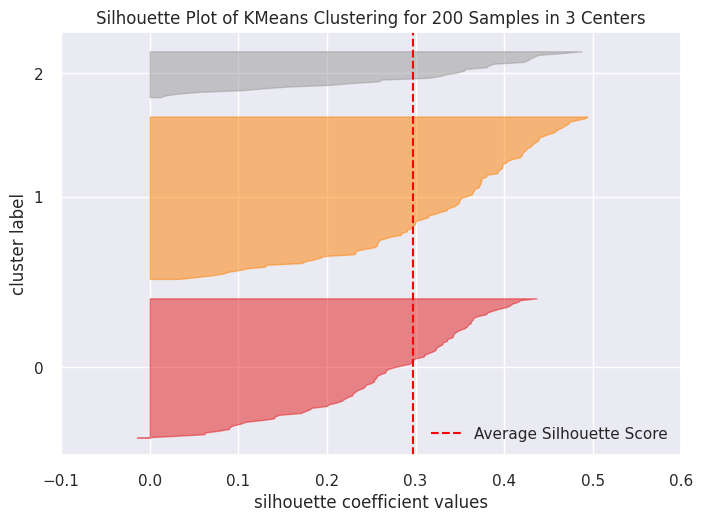

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 200 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:

visualizer = SilhouetteVisualizer(KMeans(3, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

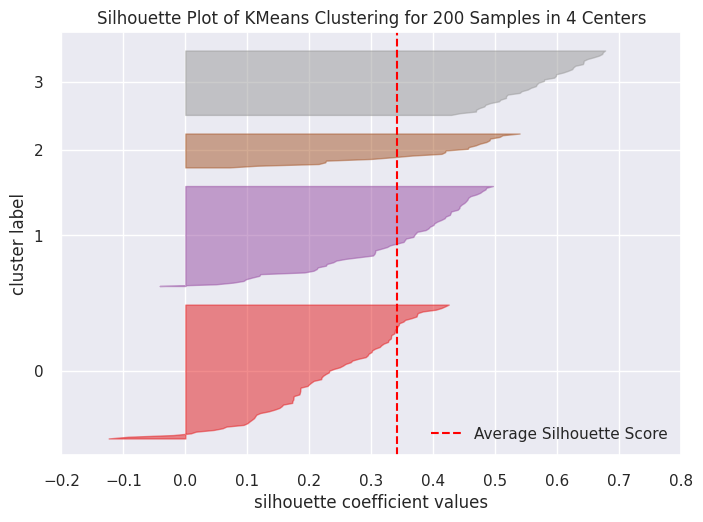

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 200 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:

visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

In [ ]:

kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(subset_scaled_df)

KMeans(n_clusters=4, random_state=0)

In [ ]:


df["K_means_segments"] = kmeans.labels_
subset_scaled_df["K_means_segments"] = kmeans.labels_

## Cluster Profiling

In [ ]:


df["K_means_segments"] = kmeans.labels_
subset_scaled_df["K_means_segments"] = kmeans.labels_


cluster_profile = df.groupby("K_means_segments")[num_col].mean()

cluster_profile["count_in_each_segments"] = (
    df.groupby("K_means_segments")["Annual_Income_(k$)"].count().values
)


cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Age,Annual_Income_(k$),Spending_Score_(1-100),count_in_each_segments
K_means_segments,,,,
0,55.638298,54.382979,48.851064,47
1,39.871795,86.102564,19.358974,39
2,28.500000,61.677778,71.766667,90
3,43.125000,26.958333,22.083333,24


In [ ]:
cluster_profile["count_in_each_segments"] = (
    df.groupby("K_means_segments")["Annual_Income_(k$)"].count().values
)

In [ ]:

cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Age,Annual_Income_(k$),Spending_Score_(1-100),count_in_each_segments
K_means_segments,,,,
0,55.638298,54.382979,48.851064,47
1,39.871795,86.102564,19.358974,39
2,28.500000,61.677778,71.766667,90
3,43.125000,26.958333,22.083333,24


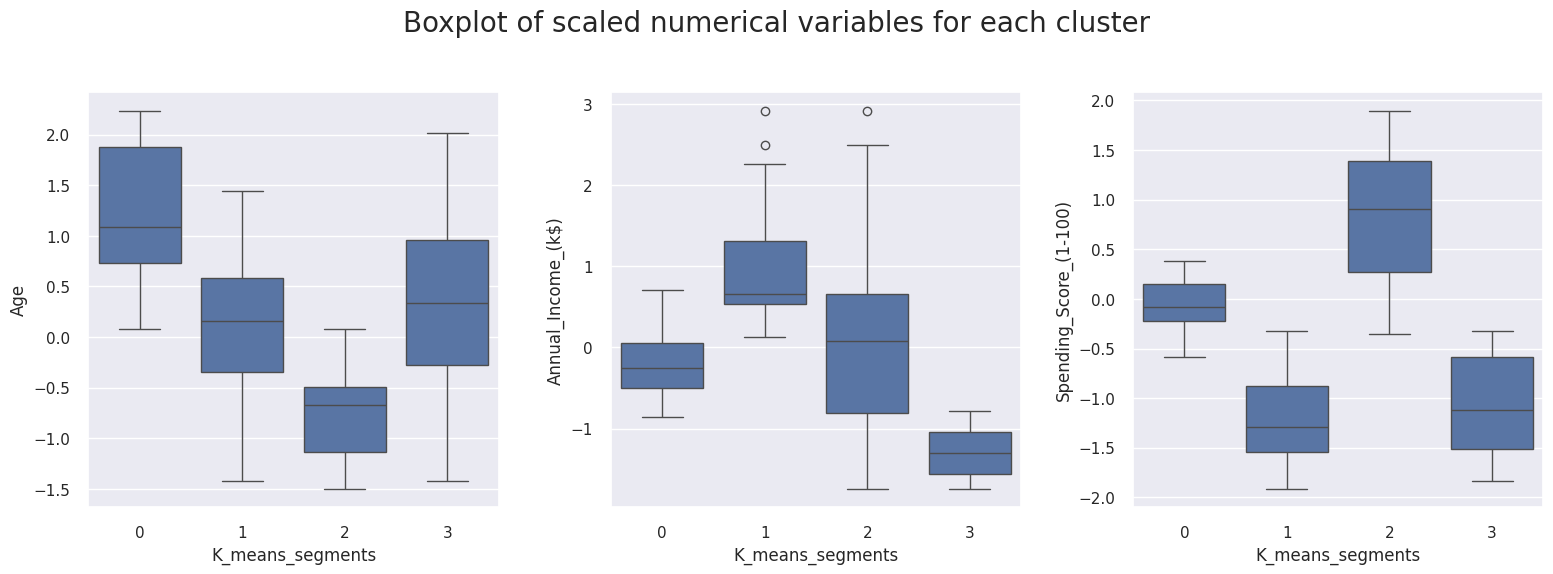

In [ ]:

fig, axes = plt.subplots(1, len(num_col), figsize=(16, 6))
fig.suptitle("Boxplot of scaled numerical variables for each cluster", fontsize=20)

for ii, col in enumerate(num_col):
    sns.boxplot(
        ax=axes[ii],
        y=subset_scaled_df[col],
        x=subset_scaled_df["K_means_segments"],
    )


fig.tight_layout(pad=2.0)
plt.show()

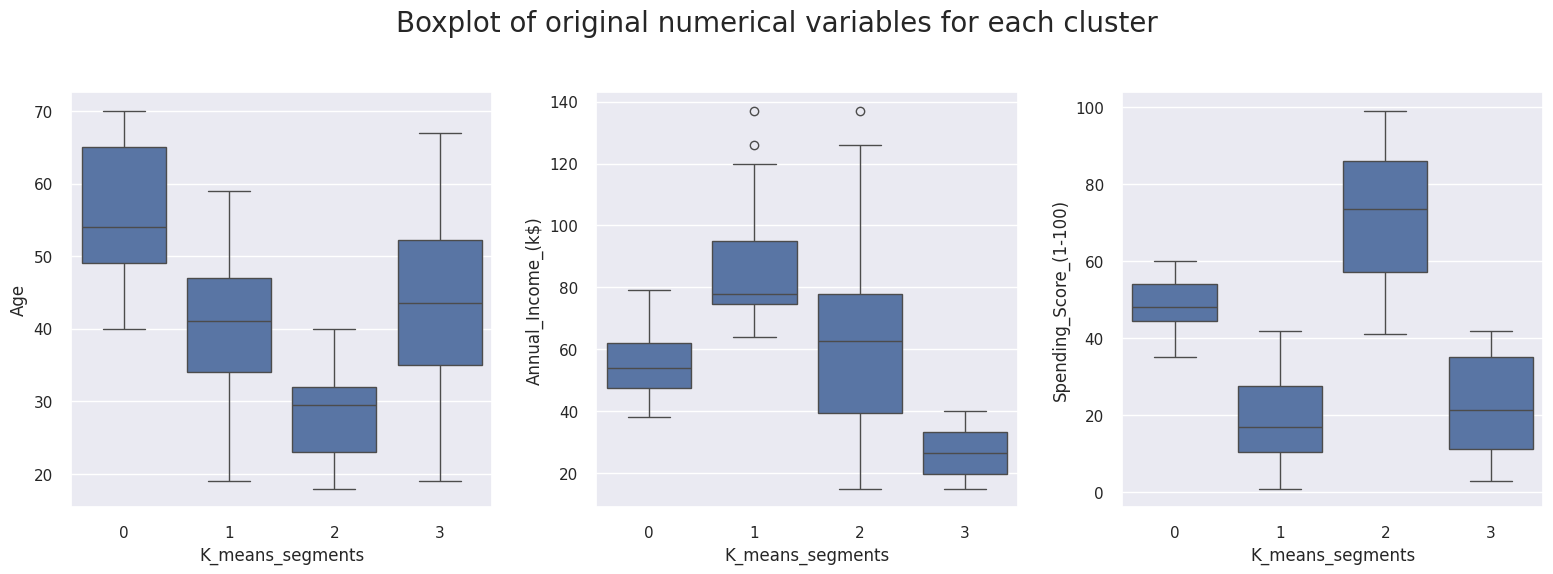

In [ ]:
fig, axes = plt.subplots(1, len(num_col), figsize=(16, 6))
fig.suptitle("Boxplot of original numerical variables for each cluster", fontsize=20)


for ii, col in enumerate(num_col):
    sns.boxplot(ax=axes[ii], y=df[col], x=df["K_means_segments"])

fig.tight_layout(pad=2.0)
plt.show()

In [ ]:
# pd.crosstab(df.K_means_segments, df.Brand).style.highlight_max(
#     color="lightgreen", axis=0
# )